In [143]:
import numpy as np

import sys
sys.path.append('./src')

Coordinates:
[[51.7027011  33.85145135]
 [61.7420549  54.60602579]
 [37.36941927  7.24097591]
 [23.10408349 41.67725491]
 [23.07270894 86.12742167]
 [19.4596246  10.24263274]
 [40.66403486 85.42304753]
 [99.13162591 66.97210283]
 [27.62115919 20.26957548]
 [55.88220778 26.42730302]]

Distance Matrix:
[[0.         0.37027657 0.48542985 0.47619294 0.95724268 0.64181412
  0.84702447 0.92907762 0.44403253 0.13683117]
 [0.37027657 0.         0.85550735 0.65436176 0.80124076 0.9842733
  0.59963206 0.63248428 0.77743675 0.46224497]
 [0.48542985 0.85550735 0.         0.59863871 1.28759058 0.29165128
  1.25675406 1.37992659 0.26133326 0.4281967 ]
 [0.47619294 0.65436176 0.59863871 0.         0.7138901  0.50823603
  0.75706715 1.28684407 0.35138746 0.58061744]
 [0.95724268 0.80124076 1.28759058 0.7138901  0.         1.22012491
  0.2827511  1.25968501 1.06022659 1.09406568]
 [0.64181412 0.9842733  0.29165128 0.50823603 1.22012491 0.
  1.25453868 1.57079633 0.20764015 0.64011505]
 [0.84702447 0.59

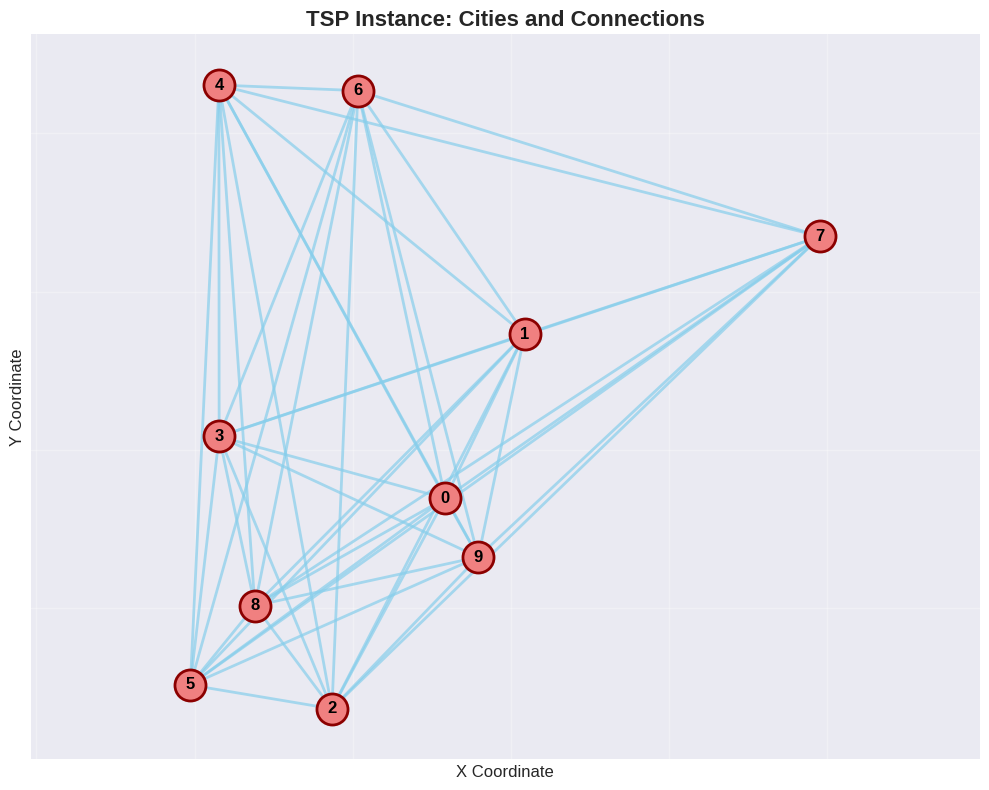

In [144]:
from tsp import TSPInstance

n_cities = 10  # Change this to the desired number of cities
tsp_instance = TSPInstance(n_cities)
print("Coordinates:")
print(tsp_instance.coords)
print("\nDistance Matrix:")
print(tsp_instance.dist_matrix)

# Plot the instance
tsp_instance.plot_tsp_instance()

In [145]:
# Classic solution

classic_route, classic_cost = tsp_instance.solve()
print("\nClassic Best Route Found:", classic_route)
print("Classic Minimum Cost of Best Route:", classic_cost)


Classic Best Route Found: [0, 1, 7, 6, 4, 3, 8, 5, 2, 9, 0]
Classic Minimum Cost of Best Route: 4.399772765790188


In [146]:
from bloch_sphere_encoding import BlochSphereEncoder

encoder = BlochSphereEncoder(tsp_instance)
bloch_tsp = encoder.get_encoded_instance()

print("\nDistance Matrix:")
print(tsp_instance.dist_matrix)


Distance Matrix:
[[0.         0.37027657 0.48542985 0.47619294 0.95724268 0.64181412
  0.84702447 0.92907762 0.44403253 0.13683117]
 [0.37027657 0.         0.85550735 0.65436176 0.80124076 0.9842733
  0.59963206 0.63248428 0.77743675 0.46224497]
 [0.48542985 0.85550735 0.         0.59863871 1.28759058 0.29165128
  1.25675406 1.37992659 0.26133326 0.4281967 ]
 [0.47619294 0.65436176 0.59863871 0.         0.7138901  0.50823603
  0.75706715 1.28684407 0.35138746 0.58061744]
 [0.95724268 0.80124076 1.28759058 0.7138901  0.         1.22012491
  0.2827511  1.25968501 1.06022659 1.09406568]
 [0.64181412 0.9842733  0.29165128 0.50823603 1.22012491 0.
  1.25453868 1.57079633 0.20764015 0.64011505]
 [0.84702447 0.59963206 1.25675406 0.75706715 0.2827511  1.25453868
  0.         0.98466396 1.06715551 0.97851422]
 [0.92907762 0.63248428 1.37992659 1.28684407 1.25968501 1.57079633
  0.98466396 0.         1.37172394 0.95210098]
 [0.44403253 0.77743675 0.26133326 0.35138746 1.06022659 0.20764015
  1

In [147]:
bloch_tsp.plot_all_cities_on_bloch_sphere()

In [148]:
bloch_tsp.plot_all_states_on_bloch_sphere()

In [149]:
from_city = 3
to_city = 1

initial_state = bloch_tsp.get_city_state(from_city)

expected_final_state = bloch_tsp.get_city_state(to_city)

travel_operator = bloch_tsp.travel_operators[from_city][to_city]
computed_final_state = initial_state.evolve(travel_operator.up).evolve(travel_operator.down)

print(f"Initial State (City {from_city}):", initial_state)
print(f"Expected Final State (City {to_city}):", expected_final_state)
print("Computed Final State after applying travel operator:", computed_final_state)
print("States match:", np.allclose(expected_final_state.data, computed_final_state.data))
print("Error: ", np.linalg.norm(expected_final_state.data - computed_final_state.data))

Initial State (City 3): Statevector([ 0.70710678+0.j        , -0.21850801+0.67249851j],
            dims=(2,))
Expected Final State (City 1): Statevector([0.70710678+0.j        , 0.5720614 +0.41562694j],
            dims=(2,))
Computed Final State after applying travel operator: Statevector([0.70710678+0.j        , 0.5720614 +0.41562694j],
            dims=(2,))
States match: True
Error:  1.6653345369377348e-16


In [150]:
routes = bloch_tsp.get_allowed_routes()
print("Allowed Routes:", len(routes))
#for route in routes:
#    print(route)

Allowed Routes: 362880


In [151]:
best_route, min_cost, mean_error = bloch_tsp.solve_brute_force()

print("Best Route Found:", best_route)
print("Minimum Cost of Best Route:", min_cost)
print("Mean Error in Final States Across All Routes:", mean_error)

Best Route Found: (0, 1, 7, 6, 4, 3, 8, 5, 2, 9, 0)
Minimum Cost of Best Route: 4.399772765790175
Mean Error in Final States Across All Routes: 1.6417589324091452e-15


In [152]:
# Compare with classic solution
classic_route, classic_cost = tsp_instance.solve()
print("\nClassic Best Route Found:", classic_route)
print("Classic Minimum Cost of Best Route:", classic_cost)
print("Quantum Best Route Found:", best_route)
print("Quantum Minimum Cost of Best Route:", min_cost)


Classic Best Route Found: [0, 1, 7, 6, 4, 3, 8, 5, 2, 9, 0]
Classic Minimum Cost of Best Route: 4.399772765790188
Quantum Best Route Found: (0, 1, 7, 6, 4, 3, 8, 5, 2, 9, 0)
Quantum Minimum Cost of Best Route: 4.399772765790175
